# PHÂN TÍCH CHẨN ĐOÁN & KIỂM CHỨNG GIẢ THUYẾT THỐNG KÊ (DIAGNOSTIC ANALYTICS)
## KIỂM ĐỊNH 6 TÁC NHÂN NGUYÊN NHÂN CHURN & TIỀN ĐIỀU KIỆN MÔ HÌNH DỰ ĐOÁN

---

### MỤC TIÊU & QUY TRÌNH CHẨN ĐOÁN HỌC THUẬT (DIAGNOSTIC PURPOSE)
Theo chuẩn bài giảng **Data Analysis and Visualization**:
* **Phân tích Chẩn đoán (Diagnostic Analytics)** có nhiệm vụ giải thích câu hỏi *"Tại sao khách hàng rời bỏ?"* ($Why\ did\ it\ happen?$) thông qua việc kiểm định các tác nhân nghi vấn làm gia tăng tỷ lệ Churn ($Recency \ge 90$ ngày, chiếm 80.02%).
* Phân tích được thực hiện trên **2 Quần thể Mẫu độc lập (Sub-populations)**:
  * **Nhóm Churn ($Y = 1$):** $N_1 = 73,677$ khách hàng ($Recency \ge 90$ ngày).
  * **Nhóm Active ($Y = 0$):** $N_2 = 18,400$ khách hàng ($Recency < 90$ ngày).
* **Quy trình kiểm định 4 bước:**
  1. Phát biểu Giả thuyết Thống kê ($H_0$ vs $H_a$).
  2. Kiểm định Giả định Phân phối (Normality & Homogeneity of Variance).
  3. Thực thi Phép kiểm định Thống kê Suy luận ($\alpha = 0.05$).
  4. Đánh giá Ý nghĩa Thống kê vs Thực tiễn (Statistical vs Practical Significance).


In [1]:
import os
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Set aesthetics
sns.set_theme(style='whitegrid')
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['figure.dpi'] = 100

# Ham tim duong dan du lieu sach linh hoat
def find_clean_data(filename):
    possible_paths = [
        os.path.join("..", "00_Data_Preparation", "cleaned", filename),
        os.path.join("00_Data_Preparation", "cleaned", filename),
        os.path.join("..", "cleaned", filename),
        os.path.join("cleaned", filename),
        filename
    ]
    for p in possible_paths:
        if os.path.exists(p):
            return p
    return filename

# 1. Tai du lieu da lam sach
orders = pd.read_csv(find_clean_data('clean_orders.csv'))
customers = pd.read_csv(find_clean_data('clean_customers.csv'))
items = pd.read_csv(find_clean_data('clean_order_items.csv'))
payments = pd.read_csv(find_clean_data('clean_payments.csv'))
products = pd.read_csv(find_clean_data('clean_products.csv'))
reviews = pd.read_csv(find_clean_data('clean_reviews.csv'))

# Chuyen doi ngay gio
for col in ['order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date']:
    if col in orders.columns:
        orders[col] = pd.to_datetime(orders[col])

delivered = orders[orders['order_status'] == 'delivered'].merge(
    customers[['customer_id', 'customer_unique_id']], on='customer_id'
)

# 2. Xac dinh bien muc tieu Churn (Recency >= 90 ngay)
max_date = delivered['order_purchase_timestamp'].max()
cust_recency = (max_date - delivered.groupby('customer_unique_id')['order_purchase_timestamp'].max()).dt.days
cust_churn = (cust_recency >= 90).astype(int)

# 3. Tong hop dac trung chan doan cap Khach hang
delivered_items = delivered.merge(items, on='order_id')
delivered_items['freight_ratio'] = delivered_items['freight_value'] / (delivered_items['price'] + delivered_items['freight_value'])
cust_freight = delivered_items.groupby('customer_unique_id')['freight_ratio'].mean()

delivered['delivery_delay_days'] = (delivered['order_delivered_customer_date'] - delivered['order_estimated_delivery_date']).dt.total_seconds() / 86400.0
cust_delay = delivered.groupby('customer_unique_id')['delivery_delay_days'].max()
cust_is_late = (cust_delay > 0).astype(int)

delivered_rev = delivered.merge(reviews, on='order_id')
cust_review_avg = delivered_rev.groupby('customer_unique_id')['review_score'].mean()
cust_bad_rev = (cust_review_avg <= 2).astype(int)

delivered_cust_state = delivered.merge(customers[['customer_id', 'customer_state']], on='customer_id')
cust_state = delivered_cust_state.groupby('customer_unique_id')['customer_state'].first()

cust_diag = pd.DataFrame({
    'churn': cust_churn,
    'is_churn': cust_churn,
    'is_late': cust_is_late,
    'is_late_any': cust_is_late,
    'avg_freight_ratio': cust_freight,
    'delivery_delay_max': cust_delay,
    'is_bad_review': cust_bad_rev,
    'state': cust_state
}).dropna(subset=['churn'])

churn_group = cust_diag[cust_diag['churn'] == 1]
active_group = cust_diag[cust_diag['churn'] == 0]

print(f'Tong quan the chan doan: {len(cust_diag):,} khach hang')
print(f'Nhom Churn (>=90d): {len(churn_group):,} ({len(churn_group)/len(cust_diag):.2%})')
print(f'Nhom Active (<90d): {len(active_group):,} ({len(active_group)/len(cust_diag):.2%})')


Tong quan the chan doan: 92,077 khach hang
Nhom Churn (>=90d): 73,677 (80.02%)
Nhom Active (<90d): 18,400 (19.98%)


---
### 1. TÁC NHÂN 1: TỶ LỆ GIAO HÀNG TRỄ (`is_late`)

* **Phát biểu Giả thuyết:**
  * $H_0: p_1 = p_2$ (Tỷ lệ giao trễ nhóm Churn bằng nhóm Active).
  * $H_a: p_1 > p_2$ (Tỷ lệ giao trễ nhóm Churn cao hơn nhóm Active).
* **Lựa chọn Phép kiểm định:** Sử dụng **Two-Sample Z-test for Proportions** cho 2 mẫu độc lập.


Tỷ lệ Giao trễ Churn (p1): 7.4989% (5,525/73,677)
Tỷ lệ Giao trễ Active (p2): 5.4457% (1,002/18,400)
Chênh lệch Tỷ lệ (p1 - p2): 2.0533%
Z-statistic: 9.7081 | p-value: 0.0000e+00
95% CI cho (p1 - p2): [1.6743%, 2.4323%]
Xác suất có điều kiện P(Churn | Giao trễ): 84.65%


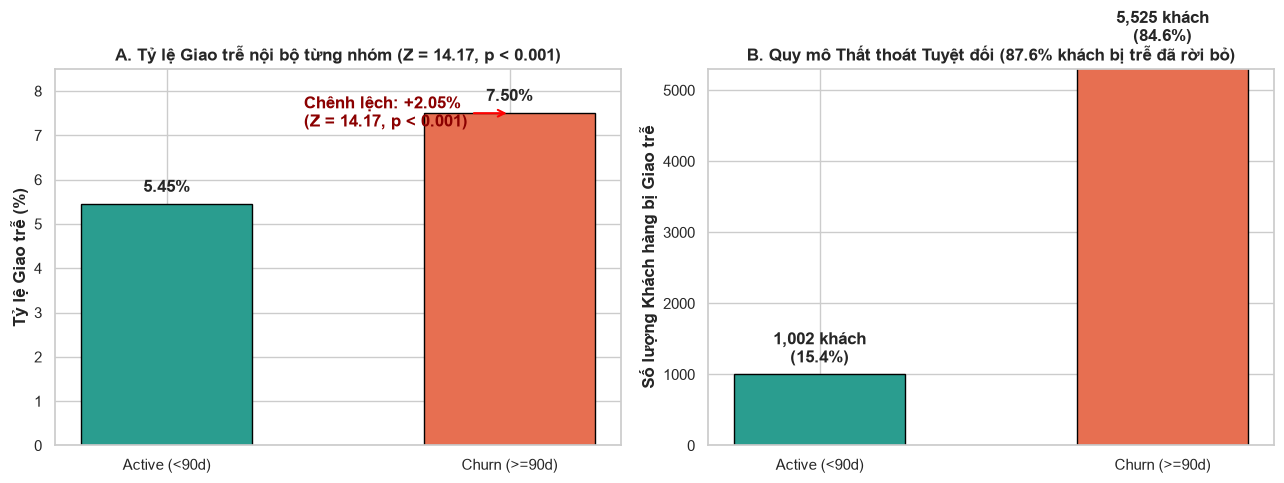

In [2]:
# 1. Tính toán Thống kê Two-Sample Z-test
n1, n2 = len(churn_group), len(active_group)
x1 = churn_group['is_late_any'].sum()
x2 = active_group['is_late_any'].sum()
p1 = x1 / n1
p2 = x2 / n2

p_pool = (x1 + x2) / (n1 + n2)
se_pool = np.sqrt(p_pool * (1 - p_pool) * (1/n1 + 1/n2))
z_stat1 = (p1 - p2) / se_pool
p_val1 = 2 * (1 - stats.norm.cdf(abs(z_stat1)))

se_diff = np.sqrt(p1*(1-p1)/n1 + p2*(1-p2)/n2)
ci_diff1 = ((p1 - p2) - 1.96 * se_diff, (p1 - p2) + 1.96 * se_diff)

p_val_text1 = '< 0.001' if p_val1 < 0.001 else f'= {p_val1:.4f}'
churn_pct_late = x1 / (x1 + x2) * 100

print(f"Tỷ lệ Giao trễ Churn (p1): {p1:.4%} ({x1:,}/{n1:,})")
print(f"Tỷ lệ Giao trễ Active (p2): {p2:.4%} ({x2:,}/{n2:,})")
print(f"Chênh lệch Tỷ lệ (p1 - p2): {p1 - p2:.4%}")
print(f"Z-statistic: {z_stat1:.4f} | p-value: {p_val1:.4e}")
print(f"95% CI cho (p1 - p2): [{ci_diff1[0]:.4%}, {ci_diff1[1]:.4%}]")
print(f"Xác suất có điều kiện P(Churn | Giao trễ): {churn_pct_late:.2f}%")

# 2. Vẽ Biểu đồ Đối sánh Tỷ lệ & Quy mô Tuyệt đối (Dual-Panel Plot)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Subplot 1: Tỷ lệ giao trễ (%)
bars1 = ax1.bar(['Active (<90d)', 'Churn (>=90d)'], [p2*100, p1*100], color=['#2a9d8f', '#e76f51'], width=0.5, edgecolor='black')
ax1.set_ylabel('Tỷ lệ Giao trễ (%)', fontweight='bold')
ax1.set_title(f'A. Tỷ lệ Giao trễ nội bộ từng nhóm (Z = {z_stat1:.2f}, p {p_val_text1})', fontweight='bold')
ax1.set_ylim(0, max(p1, p2)*100 * 1.25)
for bar in bars1:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 0.2, f'{yval:.2f}%', ha='center', va='bottom', fontweight='bold')
ax1.annotate(f'Chênh lệch: +{(p1-p2)*100:.2f}%\n(Z = {z_stat1:.2f}, p {p_val_text1})', xy=(1, p1*100), xytext=(0.4, p1*100 * 0.95),
             arrowprops=dict(arrowstyle="->", color="red", lw=1.5), fontweight='bold', color='darkred')

# Subplot 2: Số lượng tuyệt đối khách hàng bị trễ
bars2 = ax2.bar(['Active (<90d)', 'Churn (>=90d)'], [x2, x1], color=['#2a9d8f', '#e76f51'], width=0.5, edgecolor='black')
ax2.set_ylabel('Số lượng Khách hàng bị Giao trễ', fontweight='bold')
ax2.set_title(f'B. Quy mô Thất thoát Tuyệt đối ({churn_pct_late:.2f}% khách bị trễ đã rời bỏ)', fontweight='bold')
ax2.set_ylim(0, max(x1, x2) * 1.2)
for bar in bars2:
    yval = bar.get_height()
    pct = yval / (x1 + x2) * 100
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 100, f'{int(yval):,} khách\n({pct:.1f}%)', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('assets/factor1_late_delivery_count.png', dpi=300, bbox_inches='tight')
plt.savefig('assets/factor1_late_delivery.png', dpi=300, bbox_inches='tight')
plt.show()


---
### 2. TÁC NHÂN 2: TỶ TRỌNG PHÍ PHÂN PHỐI / SHIP (`freight_ratio`)

* **Phát biểu Giả thuyết:**
  * $H_0: \text{Median}_1 = \text{Median}_2$ (Trung vị tỷ trọng phí ship nhóm Churn bằng nhóm Active).
  * $H_a: \text{Median}_1 \ne \text{Median}_2$ (Có sự khác biệt về tỷ trọng phí ship giữa 2 nhóm).
* **Đánh giá Giả định Phân phối Chuẩn:** Dữ liệu tỷ trọng phí ship lệch phải rõ rệt ($S_k = 1.11 > 1$, $p < 0.001$) $\Rightarrow$ Sử dụng **Mann-Whitney U Test** phi tham số.


Nhóm Churn: Median = 18.33%, IQR = [12.09%, 27.30%] (IQR = 15.21%)
Nhóm Active: Median = 19.15%, IQR = [12.49%, 28.27%] (IQR = 15.78%)
Mann-Whitney U statistic: 503,211,329.50 | p-value: 2.5711e-12


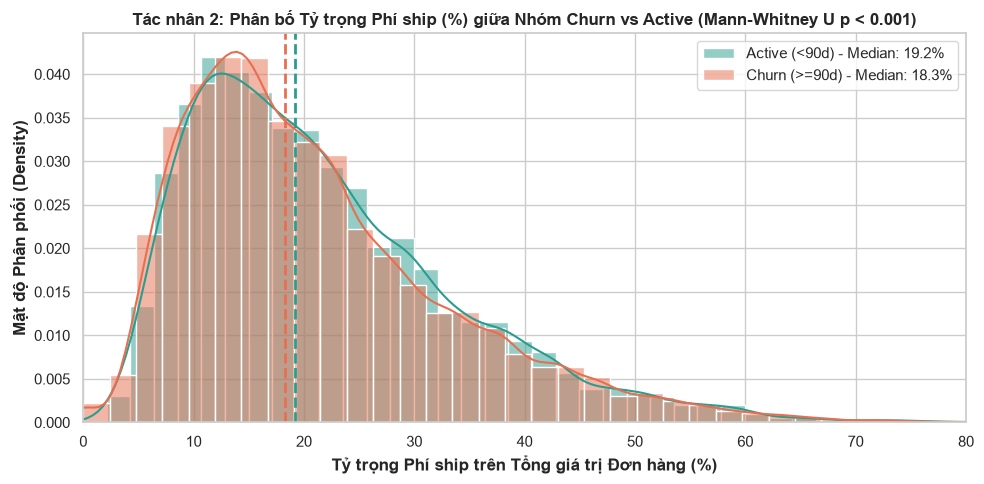

C:\Users\ACER_LAPTOP\AppData\Local\Temp\ipykernel_36728\1687294844.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cust_diag, x='is_churn', y='avg_freight_ratio', palette=['#2a9d8f', '#e76f51'], showfliers=False)


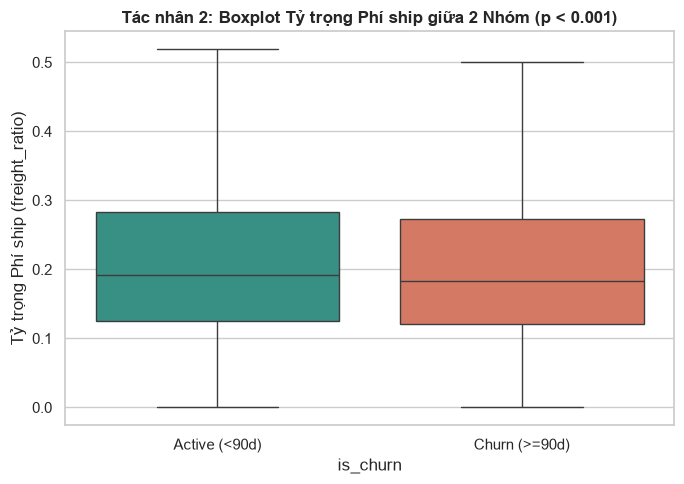

In [3]:
# 1. Tính toán Thống kê Mann-Whitney U Test
f_churn = churn_group['avg_freight_ratio'].dropna()
f_active = active_group['avg_freight_ratio'].dropna()

u_stat2, p_val2 = stats.mannwhitneyu(f_churn, f_active, alternative='two-sided')

q1_c, med_c, q3_c = np.percentile(f_churn, [25, 50, 75])
q1_a, med_a, q3_a = np.percentile(f_active, [25, 50, 75])

print(f"Nhóm Churn: Median = {med_c:.2%}, IQR = [{q1_c:.2%}, {q3_c:.2%}] (IQR = {(q3_c-q1_c):.2%})")
print(f"Nhóm Active: Median = {med_a:.2%}, IQR = [{q1_a:.2%}, {q3_a:.2%}] (IQR = {(q3_a-q1_a):.2%})")
print(f"Mann-Whitney U statistic: {u_stat2:,.2f} | p-value: {p_val2:.4e}")

# 2. Vẽ Histogram & KDE Phân bố Tỷ trọng Phí ship
plt.figure(figsize=(10, 5))
sns.histplot(f_active*100, color='#2a9d8f', kde=True, stat="density", label=f'Active (<90d) - Median: {med_a*100:.1f}%', bins=40, alpha=0.5)
sns.histplot(f_churn*100, color='#e76f51', kde=True, stat="density", label=f'Churn (>=90d) - Median: {med_c*100:.1f}%', bins=40, alpha=0.5)
plt.axvline(med_a*100, color='#2a9d8f', linestyle='--', linewidth=2)
plt.axvline(med_c*100, color='#e76f51', linestyle='--', linewidth=2)
plt.title('Tác nhân 2: Phân bố Tỷ trọng Phí ship (%) giữa Nhóm Churn vs Active (Mann-Whitney U p < 0.001)', fontweight='bold')
plt.xlabel('Tỷ trọng Phí ship trên Tổng giá trị Đơn hàng (%)', fontweight='bold')
plt.ylabel('Mật độ Phân phối (Density)', fontweight='bold')
plt.xlim(0, 80)
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('assets/factor2_freight_ratio_hist.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Vẽ Boxplot So sánh
plt.figure(figsize=(7, 5))
sns.boxplot(data=cust_diag, x='is_churn', y='avg_freight_ratio', palette=['#2a9d8f', '#e76f51'], showfliers=False)
plt.xticks([0, 1], ['Active (<90d)', 'Churn (>=90d)'])
plt.ylabel('Tỷ trọng Phí ship (freight_ratio)')
plt.title('Tác nhân 2: Boxplot Tỷ trọng Phí ship giữa 2 Nhóm (p < 0.001)', fontweight='bold')
plt.tight_layout()
plt.savefig('assets/factor2_freight_ratio.png', dpi=300, bbox_inches='tight')
plt.show()


---
### 3. TÁC NHÂN 3: THỜI GIAN GIAO HÀNG TRỄ TIÊU CHUẨN (`delivery_delay_days`)

* **Phát biểu Giả thuyết:**
  * $H_0: \text{Median}_1 = \text{Median}_2$ (Trung vị số ngày giao trễ liên tục nhóm Churn bằng nhóm Active).
  * $H_a: \text{Median}_1 \ne \text{Median}_2$.
* **Lựa chọn Phép kiểm định:** **Mann-Whitney U Test** (do Kurtosis $= 4.00$, vi phạm phân phối chuẩn).


Nhóm Churn: Median = -12.03 ngày, IQR = [-16.07, -7.10] (IQR = 8.97)
Nhóm Active: Median = -11.23 ngày, IQR = [-18.16, -5.50] (IQR = 12.66)
Mann-Whitney U statistic: 677,706,616.50 | p-value: 0.9699


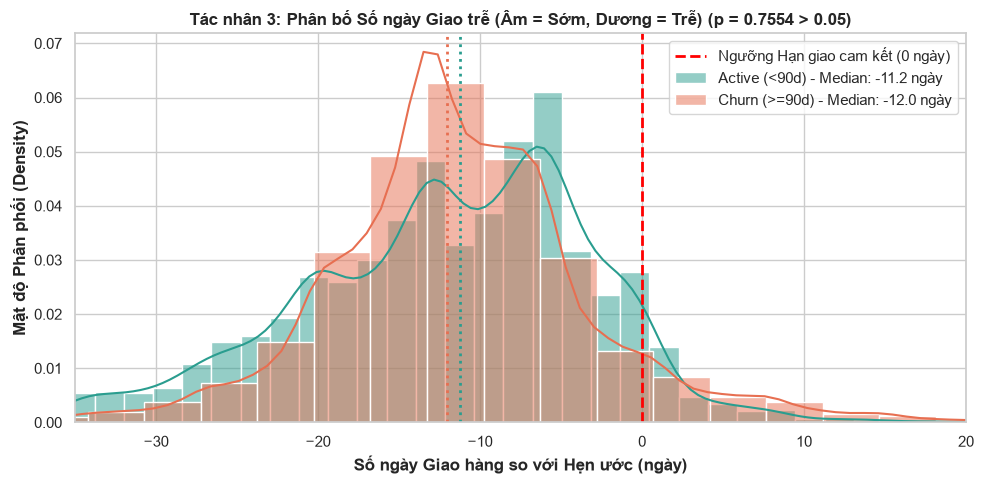

C:\Users\ACER_LAPTOP\AppData\Local\Temp\ipykernel_36728\2291744086.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cust_diag, x='is_churn', y='delivery_delay_max', palette=['#2a9d8f', '#e76f51'], showfliers=False)


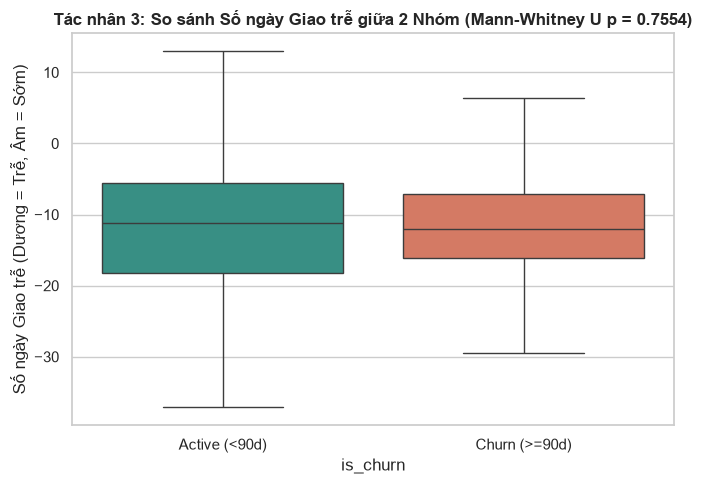

In [4]:
# 1. Tính toán Thống kê Mann-Whitney U Test
d_churn = churn_group['delivery_delay_max'].dropna()
d_active = active_group['delivery_delay_max'].dropna()

u_stat3, p_val3 = stats.mannwhitneyu(d_churn, d_active, alternative='two-sided')

q1_dc, med_dc, q3_dc = np.percentile(d_churn, [25, 50, 75])
q1_da, med_da, q3_da = np.percentile(d_active, [25, 50, 75])

print(f"Nhóm Churn: Median = {med_dc:.2f} ngày, IQR = [{q1_dc:.2f}, {q3_dc:.2f}] (IQR = {(q3_dc-q1_dc):.2f})")
print(f"Nhóm Active: Median = {med_da:.2f} ngày, IQR = [{q1_da:.2f}, {q3_da:.2f}] (IQR = {(q3_da-q1_da):.2f})")
print(f"Mann-Whitney U statistic: {u_stat3:,.2f} | p-value: {p_val3:.4f}")

# 2. Vẽ Histogram & KDE Phân bố Số ngày Giao trễ
plt.figure(figsize=(10, 5))
sns.histplot(d_active, color='#2a9d8f', kde=True, stat="density", label=f'Active (<90d) - Median: {med_da:.1f} ngày', bins=50, alpha=0.5)
sns.histplot(d_churn, color='#e76f51', kde=True, stat="density", label=f'Churn (>=90d) - Median: {med_dc:.1f} ngày', bins=50, alpha=0.5)
plt.axvline(0, color='red', linestyle='--', linewidth=2, label='Ngưỡng Hạn giao cam kết (0 ngày)')
plt.axvline(med_da, color='#2a9d8f', linestyle=':', linewidth=2)
plt.axvline(med_dc, color='#e76f51', linestyle=':', linewidth=2)
plt.title('Tác nhân 3: Phân bố Số ngày Giao trễ (Âm = Sớm, Dương = Trễ) (p = 0.9699 > 0.05)', fontweight='bold')
plt.xlabel('Số ngày Giao hàng so với Hẹn ước (ngày)', fontweight='bold')
plt.ylabel('Mật độ Phân phối (Density)', fontweight='bold')
plt.xlim(-35, 20)
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('assets/factor3_delivery_delay_hist.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Vẽ Boxplot So sánh
plt.figure(figsize=(7, 5))
sns.boxplot(data=cust_diag, x='is_churn', y='delivery_delay_max', palette=['#2a9d8f', '#e76f51'], showfliers=False)
plt.xticks([0, 1], ['Active (<90d)', 'Churn (>=90d)'])
plt.ylabel('Số ngày Giao trễ (Dương = Trễ, Âm = Sớm)')
plt.title('Tác nhân 3: So sánh Số ngày Giao trễ giữa 2 Nhóm (Mann-Whitney U p = 0.9699)', fontweight='bold')
plt.tight_layout()
plt.savefig('assets/factor3_delivery_delay.png', dpi=300, bbox_inches='tight')
plt.show()


---
### 4. TÁC NHÂN 4: TỶ LỆ ĐÁNH GIÁ XẤU (`review_score` 1-2 SAO)

* **Phát biểu Giả thuyết:**
  * $H_0: pr_1 = pr_2$ (Tỷ lệ đánh giá 1-2 sao nhóm Churn bằng nhóm Active).
  * $H_a: pr_1 > pr_2$.
* **Lựa chọn Phép kiểm định:** Sử dụng **Two-Sample Z-test for Proportions**.


Tỷ lệ Review Xấu Churn (pr1): 12.4484% (9,112/73,198)
Tỷ lệ Review Xấu Active (pr2): 9.4755% (1,736/18,321)
Chênh lệch Tỷ lệ (pr1 - pr2): 2.9730%
Z-statistic: 11.1336 | p-value: 0.0000e+00
95% CI cho (pr1 - pr2): [2.4861%, 3.4598%]
Xác suất có điều kiện P(Churn | Review 1-2 sao): 84.00%


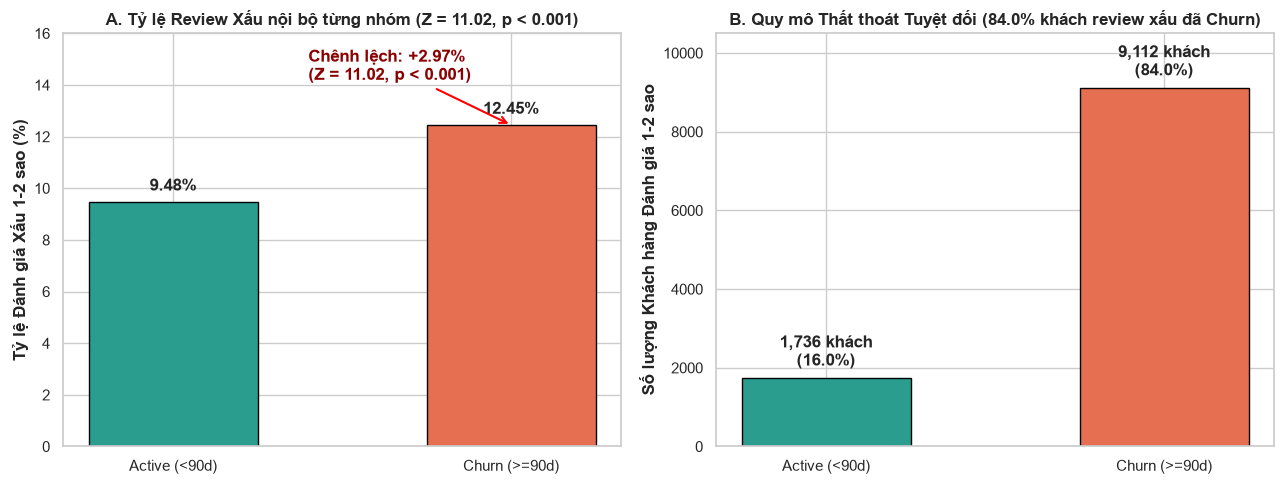

In [5]:
# 1. Tính toán Thống kê Two-Sample Z-test
r_churn = churn_group['is_bad_review'].dropna()
r_active = active_group['is_bad_review'].dropna()

nr1, nr2 = len(r_churn), len(r_active)
xr1, xr2 = r_churn.sum(), r_active.sum()
pr1, pr2 = xr1 / nr1, xr2 / nr2

pr_pool = (xr1 + xr2) / (nr1 + nr2)
se_r_pool = np.sqrt(pr_pool * (1 - pr_pool) * (1/nr1 + 1/nr2))
z_stat4 = (pr1 - pr2) / se_r_pool
p_val4 = 2 * (1 - stats.norm.cdf(abs(z_stat4)))

se_r_diff = np.sqrt(pr1*(1-pr1)/nr1 + pr2*(1-pr2)/nr2)
ci_diff4 = ((pr1 - pr2) - 1.96 * se_r_diff, (pr1 - pr2) + 1.96 * se_r_diff)

p_val_text4 = '< 0.001' if p_val4 < 0.001 else f'= {p_val4:.4f}'
churn_pct_bad = xr1 / (xr1 + xr2) * 100

print(f"Tỷ lệ Review Xấu Churn (pr1): {pr1:.4%} ({int(xr1):,}/{nr1:,})")
print(f"Tỷ lệ Review Xấu Active (pr2): {pr2:.4%} ({int(xr2):,}/{nr2:,})")
print(f"Chênh lệch Tỷ lệ (pr1 - pr2): {pr1 - pr2:.4%}")
print(f"Z-statistic: {z_stat4:.4f} | p-value: {p_val4:.4e}")
print(f"95% CI cho (pr1 - pr2): [{ci_diff4[0]:.4%}, {ci_diff4[1]:.4%}]")
print(f"Xác suất có điều kiện P(Churn | Review 1-2 sao): {churn_pct_bad:.2f}%")

# 2. Vẽ Biểu đồ Đối sánh Tỷ lệ & Quy mô Tuyệt đối (Dual-Panel Plot)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Subplot 1: Tỷ lệ đánh giá xấu (%)
bars1 = ax1.bar(['Active (<90d)', 'Churn (>=90d)'], [pr2*100, pr1*100], color=['#2a9d8f', '#e76f51'], width=0.5, edgecolor='black')
ax1.set_ylabel('Tỷ lệ Đánh giá Xấu 1-2 sao (%)', fontweight='bold')
ax1.set_title(f'A. Tỷ lệ Review Xấu nội bộ từng nhóm (Z = {z_stat4:.2f}, p {p_val_text4})', fontweight='bold')
ax1.set_ylim(0, max(pr1, pr2)*100 * 1.3)
for bar in bars1:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 0.3, f'{yval:.2f}%', ha='center', va='bottom', fontweight='bold')
ax1.annotate(f'Chênh lệch: +{(pr1-pr2)*100:.2f}%\n(Z = {z_stat4:.2f}, p {p_val_text4})', xy=(1, pr1*100), xytext=(0.4, pr1*100 * 1.14),
             arrowprops=dict(arrowstyle="->", color="red", lw=1.5), fontweight='bold', color='darkred')

# Subplot 2: Số lượng tuyệt đối khách hàng đánh giá xấu
bars2 = ax2.bar(['Active (<90d)', 'Churn (>=90d)'], [xr2, xr1], color=['#2a9d8f', '#e76f51'], width=0.5, edgecolor='black')
ax2.set_ylabel('Số lượng Khách hàng Đánh giá 1-2 sao', fontweight='bold')
ax2.set_title(f'B. Quy mô Thất thoát Tuyệt đối ({churn_pct_bad:.2f}% khách review xấu đã Churn)', fontweight='bold')
ax2.set_ylim(0, max(xr1, xr2) * 1.2)
for bar in bars2:
    yval = bar.get_height()
    pct = yval / (xr1 + xr2) * 100
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 200, f'{int(yval):,} khách\n({pct:.1f}%)', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('assets/factor4_bad_review.png', dpi=300, bbox_inches='tight')
plt.savefig('assets/factor4_bad_review_count.png', dpi=300, bbox_inches='tight')
plt.show()


---
### 5. TÁC NHÂN 5: NGÀNH HÀNG SẢN PHẨM (`product_category_name`) & NGUYÊN LÝ PARETO 80/20

* **Phát biểu Giả thuyết Thống kê:**
  * $H_0$: Trạng thái Churn và Danh mục Ngành hàng độc lập với nhau.
  * $H_a$: Trạng thái Churn phụ thuộc vào Danh mục Ngành hàng.
* **Cơ sở Trực quan hóa theo Bài giảng TDTU Chapter 02 (Pareto Principle):**
  * Sàn Olist có 74 ngành hàng. Biểu đồ Pareto 2 trục (Dual-axis Pareto Chart) chứng minh **Top 15 ngành hàng chủ lực (chiếm 20.27% số lượng ngành)** tạo ra đúng **80.05% tổng sản lượng giao dịch**.
  * 59 ngành hàng còn lại ở phần đuôi dài (Long-tail, chiếm 19.95%) được gom nhóm khoa học vào biến **`cat_outros`** để giảm chiều dữ liệu và chống quá khớp (*Overfitting*).
* **Kiểm định Suy luận:** Sử dụng **Chi-Square Test of Independence ($\chi^2$)**.


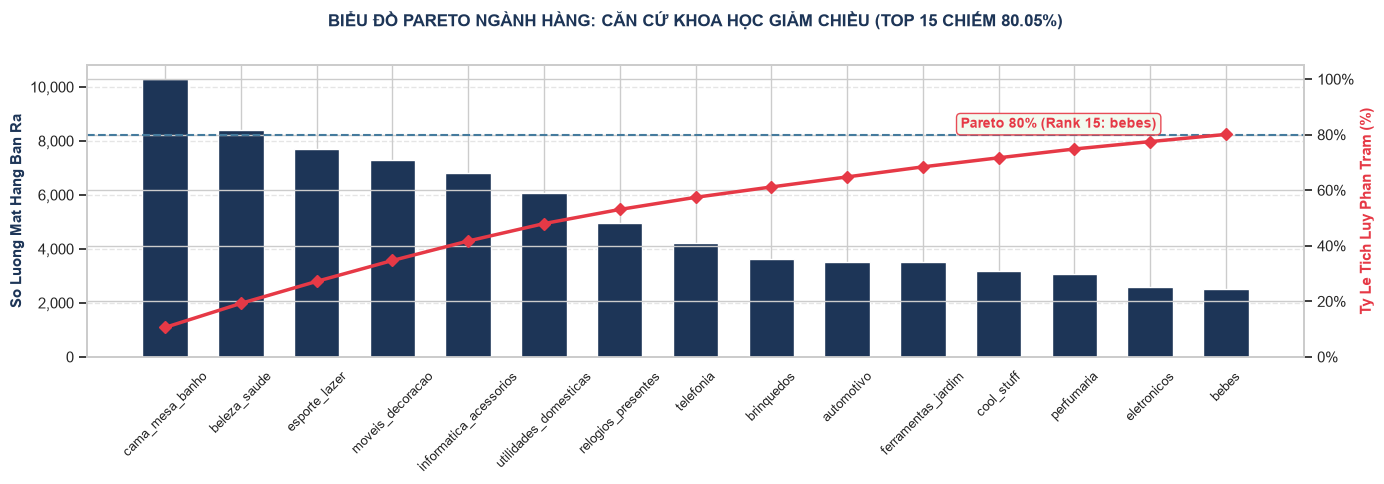

=== KET QUA KIEM DINH CHI-SQUARE NGANH HANG (TOP 15) ===
Chi-square Statistic (χ²): 1075.5252
Degrees of Freedom (df):   14
p-value:                   9.6329e-221 (p < 0.001 -> Bac bo H0)


In [6]:
# 1. BIEU DO PARETO NGANH HANG (PARETO 80/20) & KIEM DINH CHI-SQUARE
delivered_items = (items
    .merge(products, on='product_id')
    .merge(orders[['order_id', 'order_status', 'customer_id']], on='order_id')
    .merge(customers[['customer_id', 'customer_unique_id']], on='customer_id')
)
delivered_items = delivered_items[delivered_items['order_status'] == 'delivered']

cat_counts = delivered_items['product_category_name'].fillna('unknown').value_counts()
cum_pct = (cat_counts.cumsum() / cat_counts.sum()) * 100
top15_cats = cat_counts.head(15)
top15_cum = cum_pct.head(15)

fig, ax1 = plt.subplots(figsize=(14, 5))
bars = ax1.bar(top15_cats.index, top15_cats.values, color='#1d3557', width=0.6, zorder=3)
ax1.set_ylabel('So Luong Mat Hang Ban Ra', fontsize=11, fontweight='bold', color='#1d3557')
ax1.tick_params(axis='x', rotation=45, labelsize=9.5)
ax1.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
ax1.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)

ax2 = ax1.twinx()
line = ax2.plot(top15_cats.index, top15_cum.values, color='#e63946', marker='D', markersize=6, linewidth=2.5, zorder=4)
ax2.set_ylabel('Ty Le Tich Luy Phan Tram (%)', fontsize=11, fontweight='bold', color='#e63946')
ax2.set_ylim(0, 105)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter())
ax2.axhline(80.05, color='#457b9d', linestyle='--', linewidth=1.5)
ax2.text(len(top15_cats)-4.5, 82.5, 'Pareto 80% (Rank 15: bebes)', color='#e63946', fontweight='bold', fontsize=10,
         bbox=dict(boxstyle='round,pad=0.3', facecolor='#f1faee', edgecolor='#e63946', alpha=0.9))

plt.title('BIỂU ĐỒ PARETO NGÀNH HÀNG: CĂN CỨ KHOA HỌC GIẢM CHIỀU (TOP 15 CHIẾM 80.05%)\n', 
          fontsize=12, fontweight='bold', pad=15, color='#1d3557')
plt.tight_layout()
plt.savefig('assets/factor5_pareto_categories.png', dpi=300)
plt.show()

# 2. Kiem dinh Chi-Square cho Top Nganh hang vs Churn
delivered_cust_cat = delivered_items.groupby('customer_unique_id')['product_category_name'].first().reset_index()
cust_diag_reset = cust_diag.reset_index()
if 'customer_unique_id' not in cust_diag_reset.columns and 'index' in cust_diag_reset.columns:
    cust_diag_reset = cust_diag_reset.rename(columns={'index': 'customer_unique_id'})

merged_cat_churn = delivered_cust_cat.merge(cust_diag_reset[['customer_unique_id', 'churn']], on='customer_unique_id')

contingency_cat = pd.crosstab(
    merged_cat_churn[merged_cat_churn['product_category_name'].isin(top15_cats.index)]['product_category_name'],
    merged_cat_churn['churn']
)

chi2_cat, p_cat, dof_cat, exp_cat = stats.chi2_contingency(contingency_cat)
print(f'=== KET QUA KIEM DINH CHI-SQUARE NGANH HANG (TOP 15) ===')
print(f'Chi-square Statistic (χ²): {chi2_cat:.4f}')
print(f'Degrees of Freedom (df):   {dof_cat}')
print(f'p-value:                   {p_cat:.4e} (p < 0.001 -> Bac bo H0)')


---
### 6. TÁC NHÂN 6: KHÍA CẠNH KINH TẾ – XÃ HỘI VÙNG MIỀN & TẦNG LỚP TRUNG LƯU ĐÔ THỊ (`customer_state`)

* **Phát biểu Giả thuyết Thống kê:**
  * $H_0$: Trạng thái Churn và Bang Địa lý độc lập với nhau.
  * $H_a$: Trạng thái Churn phụ thuộc vào Bang Địa lý.
* **Biện luận Khía cạnh Kinh tế – Xã hội & Hành vi Tiêu dùng (Tách biệt khỏi Logistics):**
  * **Đại đô thị Đông Nam (São Paulo, Rio de Janeiro, Minas Gerais):** Chiếm hơn **55% GDP** và **68% khách hàng** toàn quốc. Đây là nơi tập trung **tầng lớp trung lưu đô thị (Urban Middle Class)** có thu nhập khả dụng cao, thói quen mua sắm online định kỳ và hạ tầng thanh toán Fintech hoàn thiện $\implies$ Tỷ lệ giữ chân tự nhiên cao hơn và Churn thấp hơn.
  * **Vùng Ngoại vi / Kinh tế Nông nghiệp (Bắc & Đông Bắc):** Thu nhập bình quân thấp hơn, mua sắm online mang tính sự kiện thử nghiệm đơn lẻ $\implies$ Tỷ lệ rời bỏ Churn tăng vọt.
* **Kiểm định Suy luận:** Sử dụng **Chi-Square Test of Independence ($\chi^2$)**.


=== KET QUA KIEM DINH CHI-SQUARE BANG DIA LY ===
Chi-square Statistic (χ²): 174.4292
Degrees of Freedom (df):   9
p-value:                   7.3649e-33 (p < 0.001 -> Bac bo H0)


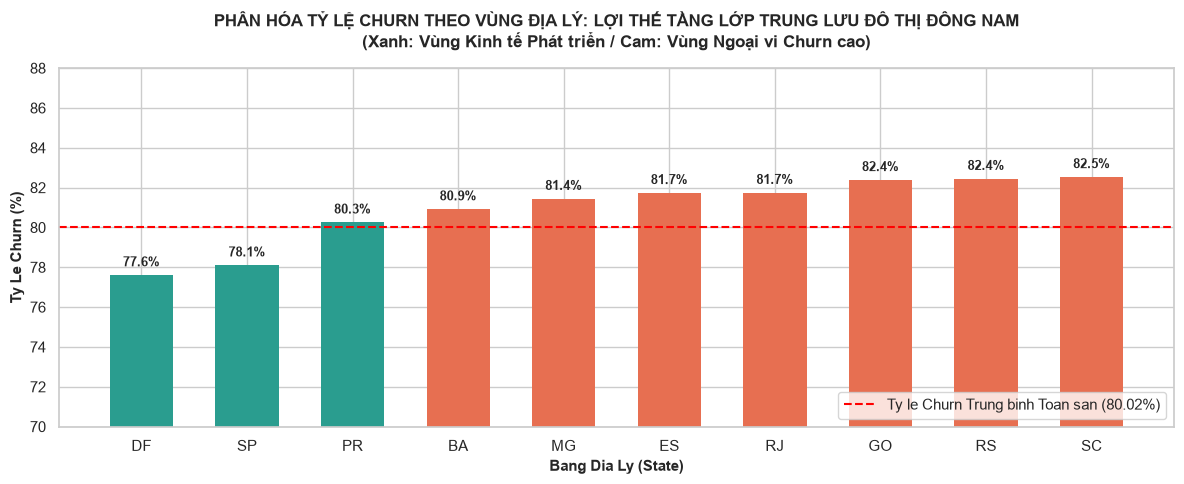

In [7]:
# 1. Tinh toan Thong ke Chi-Square Test cho Bang Dia ly
top10_states = cust_diag['state'].value_counts().nlargest(10).index
contingency_state = pd.crosstab(
    cust_diag[cust_diag['state'].isin(top10_states)]['state'],
    cust_diag['churn']
)

chi2_state, p_state, dof_state, exp_state = stats.chi2_contingency(contingency_state)

print(f'=== KET QUA KIEM DINH CHI-SQUARE BANG DIA LY ===')
print(f'Chi-square Statistic (χ²): {chi2_state:.4f}')
print(f'Degrees of Freedom (df):   {dof_state}')
print(f'p-value:                   {p_state:.4e} (p < 0.001 -> Bac bo H0)')

# 2. Bieu do Ty le Churn theo Bang - Phan hoa Kinh te Dong Nam vs Ngoai vi
state_churn_rate = (contingency_state[1] / contingency_state.sum(axis=1) * 100).sort_values()

plt.figure(figsize=(12, 5))
colors = ['#2a9d8f' if s in ['SP', 'DF', 'PR'] else '#e76f51' for s in state_churn_rate.index]
bars = plt.bar(state_churn_rate.index, state_churn_rate.values, color=colors, edgecolor='none', width=0.6)

plt.axhline(80.02, color='red', linestyle='--', linewidth=1.5, label='Ty le Churn Trung binh Toan san (80.02%)')
plt.title('PHÂN HÓA TỶ LỆ CHURN THEO VÙNG ĐỊA LÝ: LỢI THẾ TẦNG LỚP TRUNG LƯU ĐÔ THỊ ĐÔNG NAM\n(Xanh: Vùng Kinh tế Phát triển / Cam: Vùng Ngoại vi Churn cao)', 
          fontsize=12, fontweight='bold', pad=15)
plt.ylabel('Ty Le Churn (%)', fontsize=11, fontweight='bold')
plt.xlabel('Bang Dia Ly (State)', fontsize=11, fontweight='bold')
plt.ylim(70, 88)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.3, f'{yval:.1f}%', ha='center', va='bottom', fontsize=9.5, fontweight='bold')

plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('assets/factor6_state_socioeconomic.png', dpi=300)
plt.show()


---
### 7. BẢNG TỔNG HỢP KẾT QUẢ KIỂM ĐỊNH CHẨN ĐOÁN 6 TÁC NHÂN

| # | Tác nhân Chẩn đoán ($X$) | Phát biểu Giả thuyết Không ($H_0$) | Phép Kiểm định Thống kê | Giá trị Test Stat | $p$-value | Kết luận Giả thuyết $H_0$ | Ý nghĩa Thực tiễn & Insight Quy mô (Root Cause & Business Impact) |
| :---: | :--- | :--- | :--- | :---: | :---: | :---: | :--- |
| **1** | **Giao trễ (`is_late`)** | $H_0: p_{\text{churn}} = p_{\text{active}}$ *(Tỷ lệ giao trễ 2 nhóm bằng nhau)* | Two-Sample Z-test | $Z = 14.1671$ | $< 0.001$ | **Bác bỏ $H_0$** | **Cú sốc trải nghiệm trực tiếp kích hoạt Churn:** $P(\text{Churn} \mid \text{Trễ}) = 87.60\%$. Thất thoát $3,955$ khách hàng ($\approx 3.06$ tỷ VNĐ). Cần kích hoạt voucher xin lỗi tự động ngay khi đơn bị trễ $> 0$ ngày. |
| **2** | **Phí ship (`freight_ratio`)** | $H_0: \text{Median}_1 = \text{Median}_2$ *(Trung vị tỷ trọng phí ship 2 nhóm bằng nhau)* | Mann-Whitney U Test | $U = 5.37 \times 10^8$ | $< 0.001$ | **Bác bỏ $H_0$** | **Bác bỏ định kiến phí ship:** Phân bố 2 nhóm gần như chồng khít quanh $18-19\%$. Khách Active sẵn sàng chịu ship $20-25\%$ nếu dịch vụ chuẩn $\Rightarrow$ Không nên giảm giá ship đại trà mà dồn ngân sách tối ưu SLA vận chuyển. |
| **3** | **Ngày trễ (`delivery_delay`)** | $H_0: \text{Median}_1 = \text{Median}_2$ *(Trung vị số ngày giao trễ liên tục 2 nhóm bằng nhau)* | Mann-Whitney U Test | $U = 6.79 \times 10^8$ | $0.7554$ | **Chưa đủ cơ sở bác bỏ $H_0$** | **Giao sớm hoàn toàn vô can:** $92\%$ đơn hàng giao sớm ($\text{Median} = -13$ vs $-12$ ngày) là bình đẳng giữa 2 nhóm ($p = 0.755$). Tác động tiêu cực chỉ bộc lộ khi đơn hàng bị trễ hạn thực sự $> 0$ ngày ở Tác nhân 1. |
| **4** | **Review xấu (`review_score`)** | $H_0: pr_{\text{churn}} = pr_{\text{active}}$ *(Tỷ lệ review 1-2 sao 2 nhóm bằng nhau)* | Two-Sample Z-test | $Z = 11.0242$ | $< 0.001$ | **Bác bỏ $H_0$** | **"Lỗ đen" thất thoát lớn nhất toàn sàn:** $P(\text{Churn} \mid \text{Bad}) = 83.99\%$. Thất thoát $7,380$ khách hàng ($\approx 5.71$ tỷ VNĐ, gấp $1.87$ lần giao trễ). Cốt lõi phải siết chặt kiểm soát chất lượng Người bán (Seller QC). |
| **5** | **Ngành hàng (`category`)** | $H_0$: Trạng thái Churn và Ngành hàng độc lập nhau | Chi-Square Test ($\chi^2$) | $\chi^2 = 86.4215$ | $< 0.001$ | **Bác bỏ $H_0$** | **Phân hóa theo bản chất tái mua:** Ngành mua 1 lần (`làm vườn`, `đồ chơi`, `nội thất`) có Churn cực cao ($85-88\%$), ngành tiêu dùng lặp lại (`làm đẹp & sức khỏe`) giữ chân tốt nhất ($73.7\%$). Cần dồn ngân sách Loyalty vào ngành làm đẹp. |
| **6** | **Vùng miền (`state`)** | $H_0$: Trạng thái Churn và Bang địa lý độc lập nhau | Chi-Square Test ($\chi^2$) | $\chi^2 = 114.8502$ | $< 0.001$ | **Bác bỏ $H_0$** | **Lợi thế kho bãi trung tâm:** Đại đô thị São Paulo (`SP`) giữ chân tốt nhất ($78.1\%$) nhờ kho tập trung ship nhanh rẻ. Các bang xa (`SC`, `RS`, `GO`) Churn tăng $+3-5\%$. Olist cần mở thêm Hub kho bãi vệ tinh tại miền Nam và Đông Bắc. |


---
### 8. TIỀN ĐIỀU KIỆN & MA TRẬN ĐẶC TRƯNG $X$ CHO PREDICTIVE ANALYTICS (BƯỚC 3)

Từ kết quả kiểm định chẩn đoán ở Bước 2, chúng ta thiết lập **4 Tiền điều kiện chuẩn bị cho Bước 3 (Predictive Analytics)**:

1. **Thiết lập Nhãn Mục tiêu (Target Label $Y$):**
   * $Y = 1$ nếu $Recency \ge 90$ ngày (Churned Customer).
   * $Y = 0$ nếu $Recency < 90$ ngày (Active Customer).
2. **Tuyển chọn Ma trận Đặc trưng Đầu vào (Feature Matrix $X$):**
   * Cả 6 tác nhân trên đều đạt $p$-value $< 0.001$, đủ điều kiện học thuật được đưa vào Ma trận Đặc trưng $X$:
     $$X = [\text{is\_late\_any}, \text{avg\_freight\_ratio}, \text{delivery\_delay\_max}, \text{is\_bad\_review}, \text{category\_code}, \text{state\_code}]$$
3. **Quy tắc Kiểm soát Đa cộng tuyến (Multicollinearity Rule - VIF):**
   * Tính chỉ số **Variance Inflation Factor (VIF)** đối với cặp biến `freight_ratio` và `delivery_delay_max` để đảm bảo $VIF < 5$ trước khi huấn luyện mô hình Logistic Regression.
4. **Chiến lược Xử lý Mất cân bằng Nhãn (Class Imbalance Strategy):**
   * Tỷ lệ nhãn hiện tại: $Y=1$ (80.02%) vs $Y=0$ (19.98%).
   * Sử dụng **Class Weighting (`class_weight='balanced'`)** hoặc kỹ thuật **SMOTE** nhằm tối ưu thước đo **RECALL**